In [2]:
import pandas as pd
import seaborn as sns

#Se carga el dataset de titanic y se muestra las primeras filas del mismo
titanic = sns.load_dataset('titanic')
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
#Se muestra la cantidad de valores nulos por columna en el dataset
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [5]:
# Primero agregamos "Desconocido" como categoría válida
titanic['deck'] = titanic['deck'].cat.add_categories('Desconocido')

# Ahora sí podemos rellenar los huecos con esa categoría nueva
titanic['deck'] = titanic['deck'].fillna('Desconocido')

# Para 'age': rellenamos los huecos con la mediana de las edades conocidas
mediana_edad = titanic['age'].median()
titanic['age'] = titanic['age'].fillna(mediana_edad)

# Verificamos que ya no haya huecos en estas dos columnas
print(titanic[['deck', 'age']].isnull().sum())

deck    0
age     0
dtype: int64


In [6]:
# Eliminamos las filas donde falte el puerto de embarque (solo son 2 de 891)
titanic = titanic.dropna(subset=['embarked', 'embark_town'])

# Verificación final: ya no debería haber NINGÚN valor faltante en todo el dataset
print(titanic.isnull().sum())

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
deck           0
embark_town    0
alive          0
alone          0
dtype: int64


In [7]:
titanic.groupby('sex')['survived'].mean()

sex
female    0.740385
male      0.188908
Name: survived, dtype: float64

In [8]:
titanic.groupby(['pclass', 'sex'])['survived'].mean()

pclass  sex   
1       female    0.967391
        male      0.368852
2       female    0.921053
        male      0.157407
3       female    0.500000
        male      0.135447
Name: survived, dtype: float64

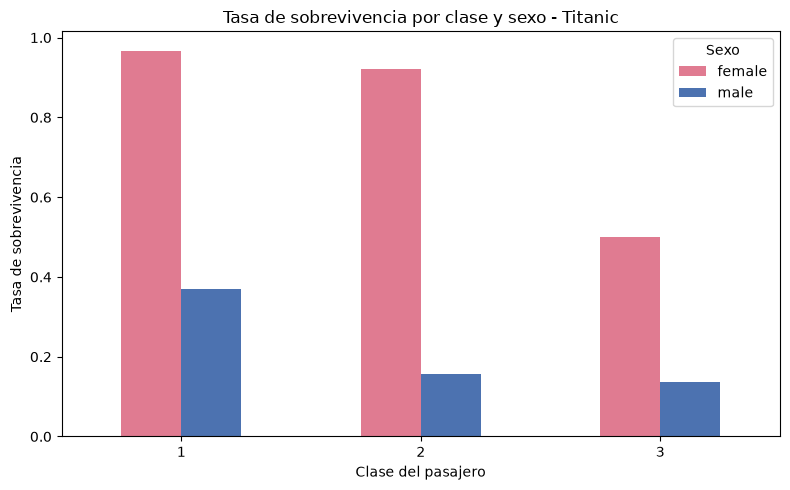

In [9]:
import matplotlib.pyplot as plt

# Preparamos los datos en formato de tabla pivote (clase en filas, sexo en columnas)
tabla = titanic.groupby(['pclass', 'sex'])['survived'].mean().unstack()

# Graficamos
tabla.plot(kind='bar', figsize=(8, 5), color=['#E07B91', '#4C72B0'])
plt.title('Tasa de sobrevivencia por clase y sexo - Titanic')
plt.xlabel('Clase del pasajero')
plt.ylabel('Tasa de sobrevivencia')
plt.xticks(rotation=0)
plt.legend(title='Sexo')
plt.tight_layout()
plt.show()